1. MODEL SCORES (75% Training Split)
Logistic Regression  Test Accuracy: 0.9622
SVM                  Test Accuracy: 0.9911
Random Forest        Test Accuracy: 0.9600
Decision Tree        Test Accuracy: 0.8244

2. CROSS-VALIDATION SCORES (5-Fold)
Logistic Regression  CV Scores: [0.97777778 0.97407407 0.94795539 0.9739777  0.95910781]
                     Mean: 0.9666 (+/- 0.0226)

SVM                  CV Scores: [0.99259259 0.97777778 0.98884758 0.98884758 0.98513011]
                     Mean: 0.9866 (+/- 0.0100)

Random Forest        CV Scores: [0.97407407 0.97037037 0.97026022 0.98141264 0.97769517]
                     Mean: 0.9748 (+/- 0.0086)

Decision Tree        CV Scores: [0.86296296 0.87407407 0.86245353 0.84758364 0.78066914]
                     Mean: 0.8455 (+/- 0.0670)

Best model (by CV): SVM with mean accuracy 0.9866


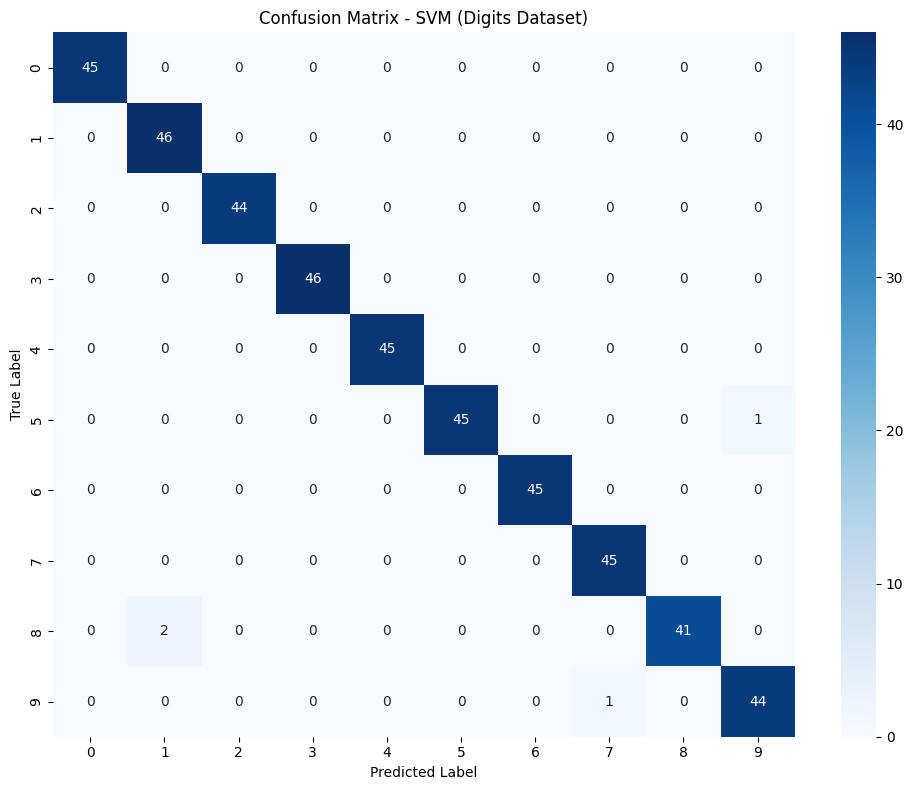

In [1]:
# ==============================================
# RESIT 2022 - QUESTION 1
# Digits Dataset - 75% Training Split
# ==============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
digits = load_digits()
X, y = digits.data, digits.target

# Split 75% training, 25% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# 1. Train and get scores (5 Marks)
print("="*60)
print("1. MODEL SCORES (75% Training Split)")
print("="*60)
for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"{name:20s} Test Accuracy: {score:.4f}")

# 2. Cross-validation with 5 folds (10 Marks)
print("\n" + "="*60)
print("2. CROSS-VALIDATION SCORES (5-Fold)")
print("="*60)
best_model = None
best_mean_score = 0
best_name = ""

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    mean_score = cv_scores.mean()
    print(f"{name:20s} CV Scores: {cv_scores}")
    print(f"{'':20s} Mean: {mean_score:.4f} (+/- {cv_scores.std()*2:.4f})\n")
    
    if mean_score > best_mean_score:
        best_mean_score = mean_score
        best_model = model
        best_name = name

print(f"Best model (by CV): {best_name} with mean accuracy {best_mean_score:.4f}")

# 3. Plot confusion matrix for best model (10 Marks)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.title(f'Confusion Matrix - {best_name} (Digits Dataset)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [2]:
# ==============================================
# RESIT 2022 - QUESTION 2b
# Face Detection using OpenCV (Webcam or Image)
# ==============================================

import cv2
import matplotlib.pyplot as plt

# Load pre-trained face detection classifier
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def detect_faces_from_image(image_path):
    """Detect faces from an image file"""
    # Read image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )
    
    # Draw rectangles around faces
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
    # Convert BGR to RGB for matplotlib display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title(f'Detected {len(faces)} face(s)')
    plt.axis('off')
    plt.show()
    
    return len(faces)

def detect_faces_webcam():
    """Real-time face detection using webcam"""
    # Open webcam
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error: Could not access webcam")
        return
    
    print("Press 'q' to quit")
    
    while True:
        # Read frame
        ret, frame = cap.read()
        if not ret:
            break
        
        # Convert to grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Detect faces
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30)
        )
        
        # Draw rectangles
        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        
        # Display FPS and face count
        cv2.putText(frame, f'Faces: {len(faces)}', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        
        # Show frame
        cv2.imshow('Face Detection', frame)
        
        # Quit on 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()

# Example usage
if __name__ == "__main__":
    # Option 1: Detect from image
    # detect_faces_from_image('path/to/image.jpg')
    
    # Option 2: Real-time webcam detection
    detect_faces_webcam()

Press 'q' to quit


In [5]:
# YOLO-based face/object detection using OpenCV DNN
def detect_with_yolo(image_path, config_path, weights_path, classes_path):
    """Object detection using YOLO"""
    # Load YOLO
    net = cv2.dnn.readNet(weights_path, config_path)
    
    with open(classes_path, 'r') as f:
        classes = [line.strip() for line in f.readlines()]
    
    # Load image
    img = cv2.imread(image_path)
    height, width = img.shape[:2]
    
    # Prepare blob
    blob = cv2.dnn.blobFromImage(img, 1/255.0, (416, 416), 
                                  swapRB=True, crop=False)
    net.setInput(blob)
    
    # Forward pass
    layer_names = net.getLayerNames()
    output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]
    outputs = net.forward(output_layers)
    
    # Process detections
    boxes, confidences, class_ids = [], [], []
    
    for output in outputs:
        for detection in output:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            
            if confidence > 0.5:
                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)
                w = int(detection[2] * width)
                h = int(detection[3] * height)
                
                x = int(center_x - w/2)
                y = int(center_y - h/2)
                
                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)
    
    # Non-max suppression
    indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
    
    # Draw boxes
    if len(indices) > 0:
        for i in indices.flatten():
            x, y, w, h = boxes[i]
            label = f"{classes[class_ids[i]]}: {confidences[i]:.2f}"
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(img, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 
                        0.5, (0, 255, 0), 2)
    
    # Display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 10))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()